In [2]:
# import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

# call repository
!rm -rf PGST
!git clone --quiet https://github.com/mickdeines/PGST/
os.chdir("PGST")

# Air properties (constants for this analysis)
RHO_AIR = 1.125      # kg/m^3
CP_AIR = 1000        # J/(kg·K)

# Unit conversions
BTU_PER_MMBTU = 1e6
W_PER_BTU_HR = 0.293071
CFM_TO_M3S = 0.000471947
F_TO_K = lambda f: (f - 32) * 5/9 + 273.15
F_TO_C = lambda f: (f - 32) * 5/9

# Approach temperature heuristic (LWT must be at least this much above EAT for effective HX)
APPROACH_TEMP_F = 10

# Entering air temperature (return air from space)
EAT_F = 60.0
EAT_K = F_TO_K(EAT_F)
print(f"Entering air temp: {EAT_F}°F = {EAT_K:.2f} K")

Entering air temp: 60.0°F = 288.71 K


In [3]:
# === EDIT THESE ===
CSV_PATH = '(REopt) 2024 Boiler Fixed Controls Input Load (MMBtu).csv'
ED_CENTER_FRACTION = 0.355487
DESIGN_EWT_HIGH_F = 190.0   # current operation (boiler)
DESIGN_EWT_LOW_F = 140.0    # heat pump scenario
OVERSIZE_FACTOR = 1.0       # 1.0 = no margin, 1.25 = 25% margin

# Boiler efficiency — only matters if CSV is fuel input rather than heat delivered
# REopt's 'Boiler Fixed Controls Input Load' is typically the THERMAL LOAD (delivered heat),
# so leave at 1.0. If your CSV represents fuel input, set to ~0.85.
BOILER_EFFICIENCY = 1.0

In [4]:
fcu_specs = pd.DataFrame([
    # name,           BTU/hr @ 190F, BTU/hr @ 160F, CFM
    ('HE-Z 50/RPM-50',     56200,    44400,    550),
    ('HE-Z 70/RPM-70',     79700,    62900,    750),
    ('HE-Z 100/RPM-100-4', 112300,   84300,   1100),
    ('HE-Z 100/RPM-100-5', 134000,  100700,   1250),
], columns=['model', 'q_190F_btuhr', 'q_160F_btuhr', 'cfm'])

# Convert to SI
fcu_specs['q_190F_W']  = fcu_specs['q_190F_btuhr'] * W_PER_BTU_HR
fcu_specs['q_160F_W']  = fcu_specs['q_160F_btuhr'] * W_PER_BTU_HR
fcu_specs['vdot_m3s']  = fcu_specs['cfm'] * CFM_TO_M3S

fcu_specs

,model,q_190F_btuhr,q_160F_btuhr,cfm,q_190F_W,q_160F_W,vdot_m3s
0,HE-Z 50/RPM-50,56200,44400,550,16470.5902,13012.3524,0.259571
1,HE-Z 70/RPM-70,79700,62900,750,23357.7587,18434.1659,0.353960
2,HE-Z 100/RPM-100-4,112300,84300,1100,32911.8733,24705.8853,0.519142
3,HE-Z 100/RPM-100-5,134000,100700,1250,39271.5140,29512.2497,0.589934


In [5]:
def fcu_capacity_at_ewt(vdot_m3s, ewt_f, eat_f=EAT_F, approach_f=APPROACH_TEMP_F):
    """
    Estimate FCU heating capacity at a given EWT using the approach-temperature heuristic.
    Assumes leaving air temperature is limited to (EWT - approach_f).
    """
    lat_f = ewt_f - approach_f                     # leaving air temp (°F)
    dT_air_f = lat_f - eat_f                       # air-side ΔT (°F)
    dT_air_K = dT_air_f * 5/9                      # convert to K (same magnitude as °C)
    q_W = RHO_AIR * vdot_m3s * CP_AIR * dT_air_K   # Q = ρ·V̇·Cp·ΔT
    return q_W, dT_air_K, lat_f

# Verify the model reproduces the 190°F spec sheet values
print("Verification — computed Q at 190°F vs. spec sheet:")
print("="*70)
for _, row in fcu_specs.iterrows():
    q_pred, dT, lat = fcu_capacity_at_ewt(row['vdot_m3s'], DESIGN_EWT_HIGH_F)
    q_spec = row['q_190F_W']
    err = 100 * (q_pred - q_spec) / q_spec
    print(f"  {row['model']:<25s} spec={q_spec/1000:6.2f} kW  pred={q_pred/1000:6.2f} kW  err={err:+5.1f}%  (LAT={lat:.0f}°F)")
print()
print("Note: prediction at 190°F uses approach-temp heuristic (LAT=180°F),")
print("which OVER-predicts vs. real spec sheet. The heuristic is meant for the")
print("LOW-EWT regime where the coil is operating near its approach-temp limit.")
print("For the 190°F case we just trust the spec sheet directly.")

Verification — computed Q at 190°F vs. spec sheet:
  HE-Z 50/RPM-50            spec= 16.47 kW  pred= 19.47 kW  err=+18.2%  (LAT=180°F)
  HE-Z 70/RPM-70            spec= 23.36 kW  pred= 26.55 kW  err=+13.7%  (LAT=180°F)
  HE-Z 100/RPM-100-4        spec= 32.91 kW  pred= 38.94 kW  err=+18.3%  (LAT=180°F)
  HE-Z 100/RPM-100-5        spec= 39.27 kW  pred= 44.25 kW  err=+12.7%  (LAT=180°F)

Note: prediction at 190°F uses approach-temp heuristic (LAT=180°F),
which OVER-predicts vs. real spec sheet. The heuristic is meant for the
LOW-EWT regime where the coil is operating near its approach-temp limit.
For the 190°F case we just trust the spec sheet directly.


In [6]:
# Compute capacity at the low EWT design point (140°F)
fcu_specs['q_lowEWT_W'], fcu_specs['dT_air_K_lowEWT'], fcu_specs['LAT_F_lowEWT'] = zip(*[
    fcu_capacity_at_ewt(v, DESIGN_EWT_LOW_F) for v in fcu_specs['vdot_m3s']
])

# Reduction factor: how much capacity is lost going from 190°F to 140°F EWT
fcu_specs['capacity_ratio_lowEWT'] = fcu_specs['q_lowEWT_W'] / fcu_specs['q_190F_W']
fcu_specs['scaling_factor'] = 1.0 / fcu_specs['capacity_ratio_lowEWT']

print(f"FCU capacity comparison: {DESIGN_EWT_HIGH_F:.0f}°F EWT vs {DESIGN_EWT_LOW_F:.0f}°F EWT")
print("="*80)
display(fcu_specs[['model', 'q_190F_W', 'q_lowEWT_W', 'capacity_ratio_lowEWT', 'scaling_factor']]
        .style.format({
            'q_190F_W': '{:,.0f} W',
            'q_lowEWT_W': '{:,.0f} W',
            'capacity_ratio_lowEWT': '{:.1%}',
            'scaling_factor': '{:.2f}×'
        }))

FCU capacity comparison: 190°F EWT vs 140°F EWT


,model,q_190F_W,q_lowEWT_W,capacity_ratio_lowEWT,scaling_factor
0,HE-Z 50/RPM-50,"16,471 W","11,356 W",68.9%,1.45×
1,HE-Z 70/RPM-70,"23,358 W","15,486 W",66.3%,1.51×
2,HE-Z 100/RPM-100-4,"32,912 W","22,712 W",69.0%,1.45×
3,HE-Z 100/RPM-100-5,"39,272 W","25,810 W",65.7%,1.52×


In [7]:
# Try to load CSV — handle a couple of common formats from REopt exports
df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df)} rows")
print("Columns:", df.columns.tolist())
print(df.head())

Loaded 8760 rows
Columns: ['Hour', 'Heating Load (MMBtu/hr)']
   Hour  Heating Load (MMBtu/hr)
0     1                 0.174264
1     2                 0.178536
2     3                 0.185873
3     4                 0.190619
4     5                 0.203592


In [8]:
# Identify which column holds the load values. REopt CSVs sometimes have an
# 'hour' column and a 'load' column, sometimes just a single column.
# Pick the column with numeric values that isn't an index/hour column.

load_col = None
for c in df.columns:
    if df[c].dtype in [np.float64, np.int64]:
        # skip obvious hour/index columns
        if 'hour' in c.lower() or 'index' in c.lower():
            continue
        load_col = c
        break

if load_col is None:
    # fallback: last numeric column
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    load_col = numeric_cols[-1]

print(f"Using load column: '{load_col}'")

# Boiler load in MMBtu (per hour, since hourly data)
df['boiler_load_MMBtu_hr'] = df[load_col]

# If CSV is fuel input, convert to delivered heat
df['boiler_delivered_MMBtu_hr'] = df['boiler_load_MMBtu_hr'] * BOILER_EFFICIENCY

# Scale to Ed. Center
df['ed_center_MMBtu_hr'] = df['boiler_delivered_MMBtu_hr'] * ED_CENTER_FRACTION

# Convert to kW (1 MMBtu/hr = 293.071 kW)
df['ed_center_kW'] = df['ed_center_MMBtu_hr'] * 1e6 * W_PER_BTU_HR / 1000

print(f"\nEd. Center load summary ({ED_CENTER_FRACTION:.0%} of boiler):")
print(f"  Annual total:        {df['ed_center_MMBtu_hr'].sum():>10,.1f} MMBtu/yr")
print(f"  Annual total:        {df['ed_center_kW'].sum():>10,.0f} kWh/yr")
print(f"  Peak hourly load:    {df['ed_center_kW'].max():>10,.1f} kW")
print(f"  Mean (non-zero):     {df.loc[df['ed_center_kW']>0, 'ed_center_kW'].mean():>10,.1f} kW")
print(f"  Hours with load>0:   {(df['ed_center_kW']>0).sum():>10,d} hr/yr")

Using load column: 'Heating Load (MMBtu/hr)'

Ed. Center load summary (36% of boiler):
  Annual total:             300.2 MMBtu/yr
  Annual total:            87,971 kWh/yr
  Peak hourly load:          39.4 kW
  Mean (non-zero):           10.0 kW
  Hours with load>0:        8,760 hr/yr


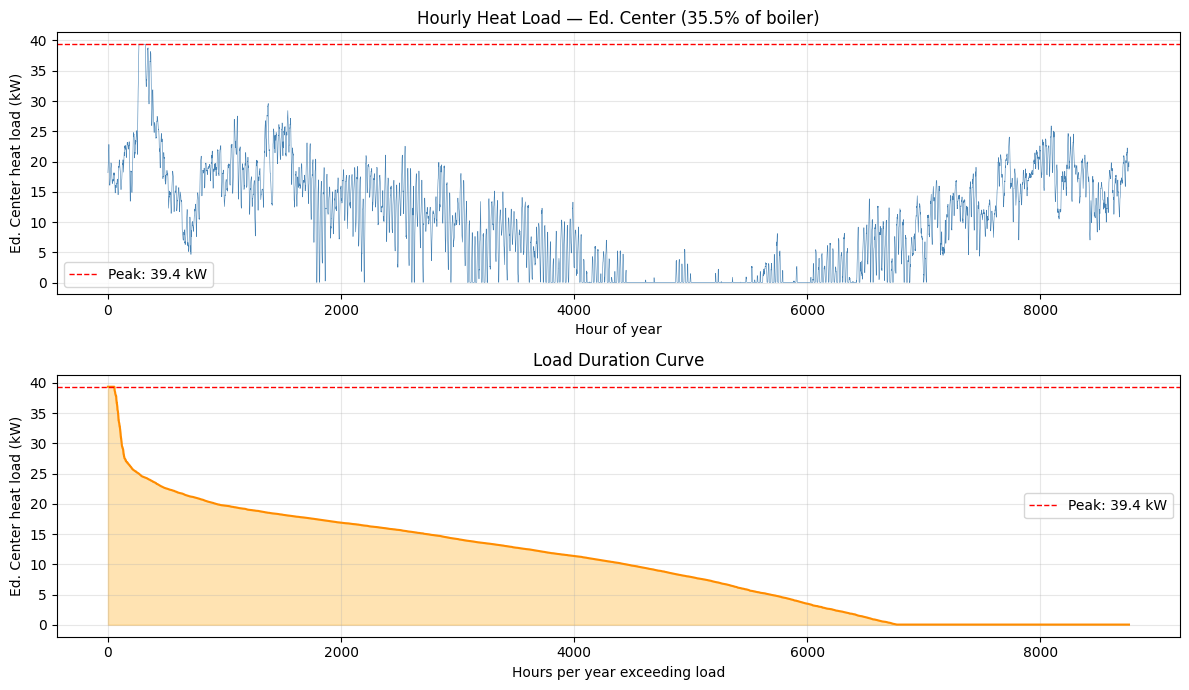

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# Hourly profile across the year
axes[0].plot(df.index, df['ed_center_kW'], lw=0.4, color='steelblue')
axes[0].axhline(df['ed_center_kW'].max(), color='red', ls='--', lw=1,
                label=f"Peak: {df['ed_center_kW'].max():.1f} kW")
axes[0].set_xlabel('Hour of year')
axes[0].set_ylabel('Ed. Center heat load (kW)')
axes[0].set_title(f'Hourly Heat Load — Ed. Center (35.5% of boiler)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Load duration curve
ldc = df['ed_center_kW'].sort_values(ascending=False).reset_index(drop=True)
axes[1].plot(ldc.index, ldc.values, color='darkorange')
axes[1].fill_between(ldc.index, ldc.values, alpha=0.3, color='orange')
axes[1].axhline(df['ed_center_kW'].max(), color='red', ls='--', lw=1,
                label=f"Peak: {df['ed_center_kW'].max():.1f} kW")
axes[1].set_xlabel('Hours per year exceeding load')
axes[1].set_ylabel('Ed. Center heat load (kW)')
axes[1].set_title('Load Duration Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
peak_kW = df['ed_center_kW'].max()
design_kW = peak_kW * OVERSIZE_FACTOR

print(f"Ed. Center peak load:    {peak_kW:.1f} kW")
print(f"Oversize factor:         {OVERSIZE_FACTOR:.2f}×")
print(f"Design target:           {design_kW:.1f} kW")
print()

results = []
for _, row in fcu_specs.iterrows():
    n_at_190 = int(np.ceil(design_kW * 1000 / row['q_190F_W']))
    n_at_low = int(np.ceil(design_kW * 1000 / row['q_lowEWT_W']))
    results.append({
        'model': row['model'],
        'Q @ 190°F (kW)': row['q_190F_W'] / 1000,
        'Q @ 140°F (kW)': row['q_lowEWT_W'] / 1000,
        f'# units @ 190°F': n_at_190,
        f'# units @ 140°F': n_at_low,
        'Additional units': n_at_low - n_at_190,
        'Scale-up factor': f"{n_at_low/n_at_190:.2f}×",
    })

results_df = pd.DataFrame(results)
display(results_df.style.format({
    'Q @ 190°F (kW)': '{:.1f}',
    'Q @ 140°F (kW)': '{:.1f}',
}))

Ed. Center peak load:    39.4 kW
Oversize factor:         1.00×
Design target:           39.4 kW



,model,Q @ 190°F (kW),Q @ 140°F (kW),# units @ 190°F,# units @ 140°F,Additional units,Scale-up factor
0,HE-Z 50/RPM-50,16.5,11.4,3,4,1,1.33×
1,HE-Z 70/RPM-70,23.4,15.5,2,3,1,1.50×
2,HE-Z 100/RPM-100-4,32.9,22.7,2,2,0,1.00×
3,HE-Z 100/RPM-100-5,39.3,25.8,2,2,0,1.00×


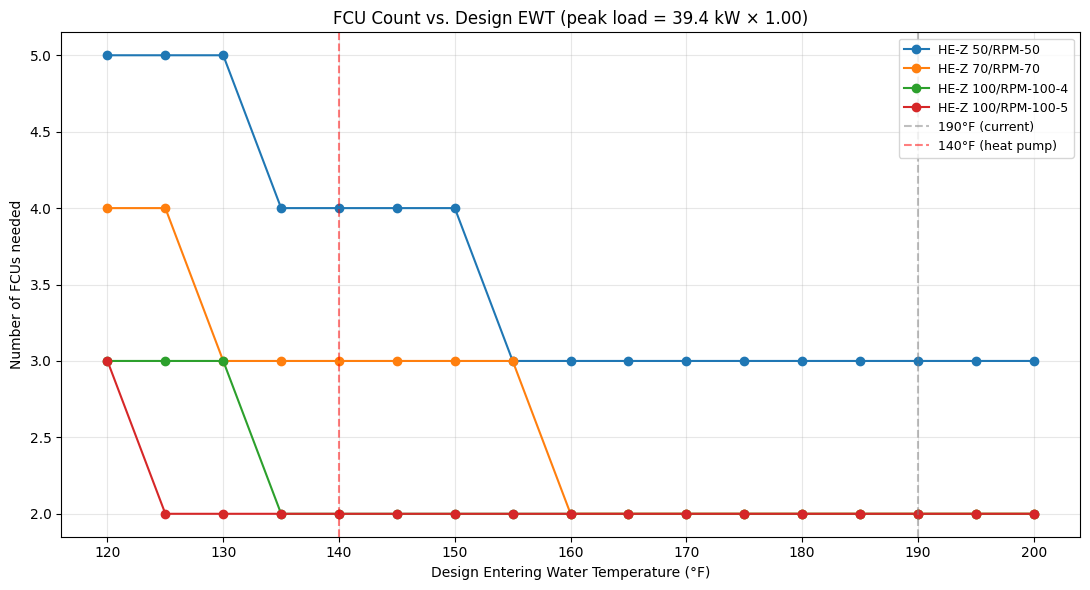

In [11]:
ewt_sweep_F = np.arange(120, 201, 5)

fig, ax = plt.subplots(figsize=(11, 6))

for _, row in fcu_specs.iterrows():
    counts = []
    for ewt in ewt_sweep_F:
        # use approach-temp heuristic to estimate capacity at each EWT
        q_W, _, _ = fcu_capacity_at_ewt(row['vdot_m3s'], ewt)
        # cap at spec-sheet 190°F rating (heuristic over-predicts at high EWT)
        q_W = min(q_W, row['q_190F_W'])
        n = np.ceil(design_kW * 1000 / q_W)
        counts.append(n)
    ax.plot(ewt_sweep_F, counts, marker='o', label=row['model'])

ax.axvline(DESIGN_EWT_HIGH_F, color='gray', ls='--', alpha=0.5, label=f'{DESIGN_EWT_HIGH_F:.0f}°F (current)')
ax.axvline(DESIGN_EWT_LOW_F, color='red', ls='--', alpha=0.5, label=f'{DESIGN_EWT_LOW_F:.0f}°F (heat pump)')
ax.set_xlabel('Design Entering Water Temperature (°F)')
ax.set_ylabel('Number of FCUs needed')
ax.set_title(f'FCU Count vs. Design EWT (peak load = {peak_kW:.1f} kW × {OVERSIZE_FACTOR:.2f})')
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Build configurations to compare
# For each model: show (a) min units to meet load at 190F, and (b) min units to meet load at 140F.
# Both configurations meet the peak load — the difference shows the additional units required
# when moving to the lower-temperature heat pump scenario.

configs = []
for _, row in fcu_specs.iterrows():
    q190 = row['q_190F_W'] / 1000  # kW per unit
    q140 = row['q_lowEWT_W'] / 1000
    n190 = int(np.ceil(design_kW / q190))
    n140 = int(np.ceil(design_kW / q140))

    # Config A: minimum count to meet load at 190°F
    configs.append({
        'label': f"{row['model'].split('/')[0]}\n{n190}× @ 190°F",
        'model': row['model'],
        'n_units': n190,
        'q_per_unit_kW': q190,
        'ewt': 190,
        'group': row['model'],
    })
    # Config B: minimum count to meet load at 140°F
    configs.append({
        'label': f"{row['model'].split('/')[0]}\n{n140}× @ 140°F",
        'model': row['model'],
        'n_units': n140,
        'q_per_unit_kW': q140,
        'ewt': 140,
        'group': row['model'],
    })

configs_df = pd.DataFrame(configs)
configs_df['total_capacity_kW'] = configs_df['n_units'] * configs_df['q_per_unit_kW']
configs_df['meets_load'] = configs_df['total_capacity_kW'] >= design_kW
configs_df

,label,model,n_units,q_per_unit_kW,ewt,group,total_capacity_kW,meets_load
0,HE-Z 50\n3× @ 190°F,HE-Z 50/RPM-50,3,16.470590,190,HE-Z 50/RPM-50,49.411771,True
1,HE-Z 50\n4× @ 140°F,HE-Z 50/RPM-50,4,11.356225,140,HE-Z 50/RPM-50,45.424899,True
2,HE-Z 70\n2× @ 190°F,HE-Z 70/RPM-70,2,23.357759,190,HE-Z 70/RPM-70,46.715517,True
3,HE-Z 70\n3× @ 140°F,HE-Z 70/RPM-70,3,15.485761,140,HE-Z 70/RPM-70,46.457283,True
4,HE-Z 100\n2× @ 190°F,HE-Z 100/RPM-100-4,2,32.911873,190,HE-Z 100/RPM-100-4,65.823747,True
5,HE-Z 100\n2× @ 140°F,HE-Z 100/RPM-100-4,2,22.712449,140,HE-Z 100/RPM-100-4,45.424899,True
6,HE-Z 100\n2× @ 190°F,HE-Z 100/RPM-100-5,2,39.271514,190,HE-Z 100/RPM-100-5,78.543028,True
7,HE-Z 100\n2× @ 140°F,HE-Z 100/RPM-100-5,2,25.809602,140,HE-Z 100/RPM-100-5,51.619203,True


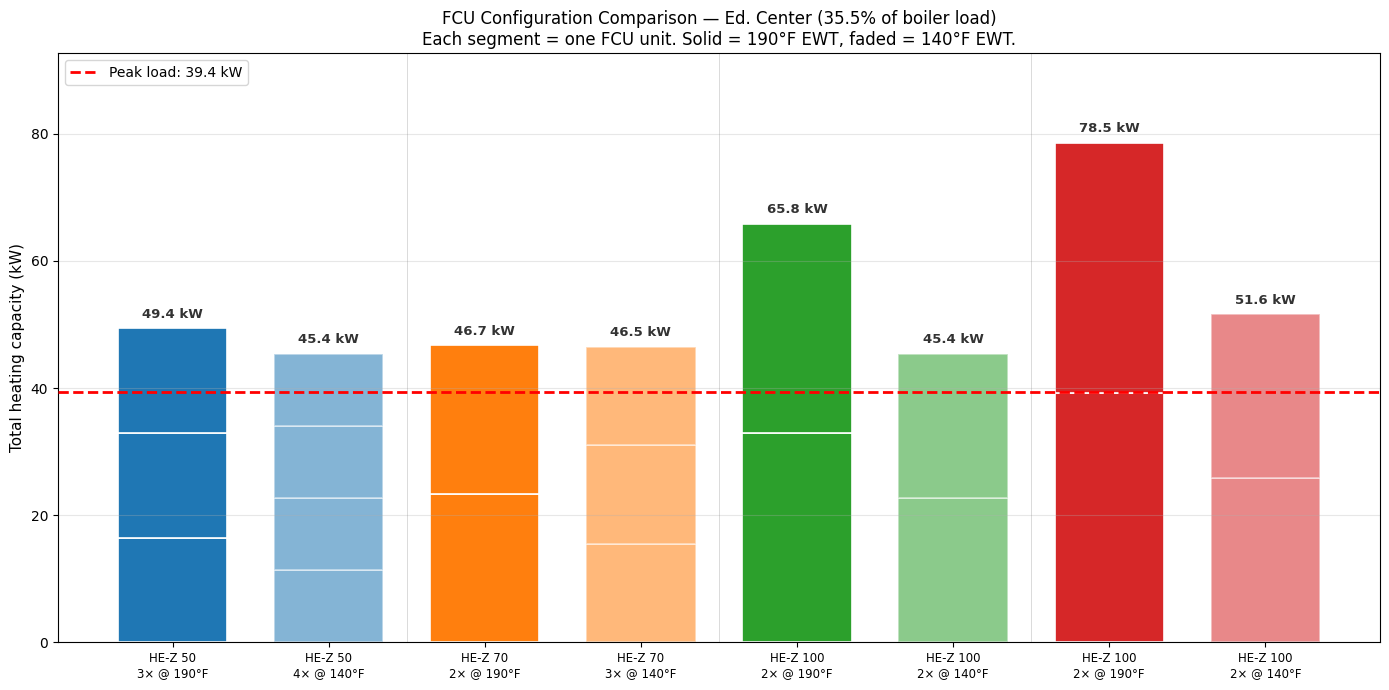


Reading the chart:
  Solid bar  = minimum units required at 190°F EWT (current boiler)
  Faded bar  = minimum units required at 140°F EWT (heat pump scenario)
  Both configurations meet peak load — the difference is the additional
  FCU capacity needed when running at lower EWT.


In [13]:
# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(14, 7))

# Color scheme: one base color per model, lighter shade for 140°F EWT
model_colors = {
    'HE-Z 50/RPM-50':     '#1f77b4',
    'HE-Z 70/RPM-70':     '#ff7f0e',
    'HE-Z 100/RPM-100-4': '#2ca02c',
    'HE-Z 100/RPM-100-5': '#d62728',
}

x_positions = np.arange(len(configs_df))
bar_width = 0.7

for i, (_, cfg) in enumerate(configs_df.iterrows()):
    base_color = model_colors[cfg['model']]
    # lighter shade for 140°F to visually distinguish
    alpha = 1.0 if cfg['ewt'] == 190 else 0.55

    bottom = 0
    q_per = cfg['q_per_unit_kW']
    for unit_idx in range(cfg['n_units']):
        ax.bar(x_positions[i], q_per, bottom=bottom, width=bar_width,
               color=base_color, alpha=alpha,
               edgecolor='white', linewidth=1.2)
        bottom += q_per

    # Label total capacity above each bar
    total = cfg['total_capacity_kW']
    ax.text(x_positions[i], total + design_kW*0.03,
            f"{total:.1f} kW",
            ha='center', va='bottom', fontsize=9.5, fontweight='bold',
            color='#333333')

# Peak load reference line
ax.axhline(design_kW, color='red', linestyle='--', linewidth=2,
           label=f'Peak load: {design_kW:.1f} kW', zorder=10)

# Axis formatting
ax.set_xticks(x_positions)
ax.set_xticklabels(configs_df['label'], rotation=0, fontsize=8.5)
ax.set_ylabel('Total heating capacity (kW)', fontsize=11)
ax.set_title(f'FCU Configuration Comparison — Ed. Center (35.5% of boiler load)\n'
             f'Each segment = one FCU unit. Solid = 190°F EWT, faded = 140°F EWT.',
             fontsize=12)
ax.legend(loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(configs_df['total_capacity_kW'].max(), design_kW) * 1.18)

# Vertical separators between model groups (2 bars per group)
for boundary in [1.5, 3.5, 5.5]:
    ax.axvline(boundary, color='gray', linewidth=0.5, alpha=0.4)

plt.tight_layout()
plt.show()

print()
print('Reading the chart:')
print('  Solid bar  = minimum units required at 190°F EWT (current boiler)')
print('  Faded bar  = minimum units required at 140°F EWT (heat pump scenario)')
print('  Both configurations meet peak load — the difference is the additional')
print('  FCU capacity needed when running at lower EWT.')

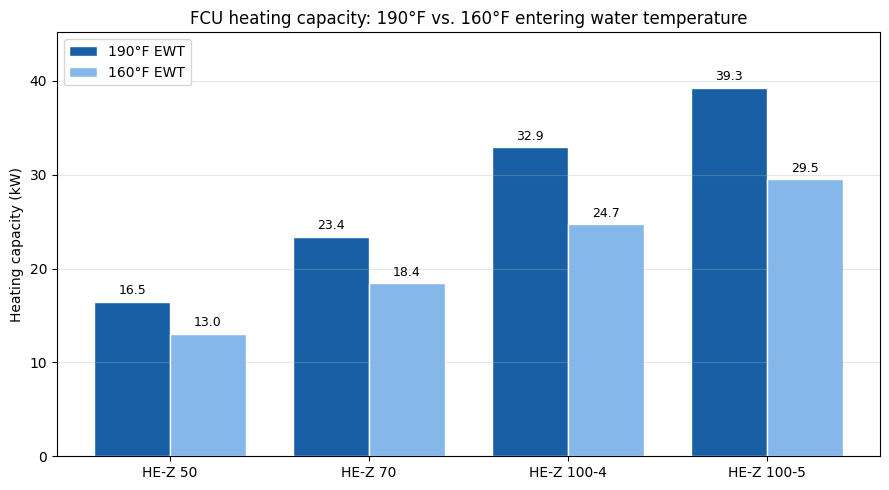

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

# Shorten model names: 'HE-Z 50/RPM-50' → 'HE-Z 50', 'HE-Z 100/RPM-100-4' → 'HE-Z 100-4'
def short_name(model):
    base, variant = model.split('/')
    parts = variant.split('-')
    if len(parts) >= 3:
        return f'{base}-{parts[-1]}'
    return base

models = [short_name(m) for m in fcu_specs['model']]
q_190 = fcu_specs['q_190F_W'].values / 1000  # convert W → kW
q_160 = fcu_specs['q_160F_W'].values / 1000

x = np.arange(len(models))
bar_width = 0.38

b190 = ax.bar(x - bar_width/2, q_190, bar_width, label='190°F EWT',
              color='#185FA5', edgecolor='white')
b160 = ax.bar(x + bar_width/2, q_160, bar_width, label='160°F EWT',
              color='#85B7EB', edgecolor='white')

# Value labels on top of each bar
for bars in (b190, b160):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                f'{h:.1f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Heating capacity (kW)')
ax.set_title('FCU heating capacity: 190°F vs. 160°F entering water temperature')
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(q_190) * 1.15)

plt.tight_layout()
plt.show()